# Olist Data Warehouse — Analytics Report

This notebook queries the Star Schema in PostgreSQL and visualizes key business insights from the Olist Brazilian E-Commerce dataset.

**Data Warehouse specs:**
- 1 fact table (`fact_order_items`): 112,650 rows
- 4 dimension tables: `dim_date`, `dim_customer`, `dim_product`, `dim_seller`
- Date range: Sep 2016 – Oct 2018
- Source: [Kaggle - Olist Brazilian E-Commerce](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)


## 1. Setup & Connection

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os
import warnings

warnings.filterwarnings('ignore')

# Style
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'figure.dpi': 100,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
})

COLORS = {
    'primary': '#1B2A4A',
    'blue': '#3B82C4',
    'green': '#2ECC71',
    'red': '#E74C3C',
    'orange': '#F39C12',
    'gray': '#95A5A6',
    'palette': ['#3B82C4', '#1B2A4A', '#2ECC71', '#F39C12', '#E74C3C', '#9B59B6']
}

print("Libraries loaded successfully")

Libraries loaded successfully


In [14]:
# Connect to PostgreSQL
load_dotenv()

engine = create_engine(
    f"postgresql://{os.getenv('DB_USER', 'postgres')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST', 'localhost')}:{os.getenv('DB_PORT', '5432')}"
    f"/{os.getenv('DB_NAME', 'olist_dw')}"
)

# Quick check
row_counts = pd.read_sql("""
    SELECT 'fact_order_items' AS tbl, COUNT(*) AS rows FROM fact_order_items
    UNION ALL SELECT 'dim_date', COUNT(*) FROM dim_date
    UNION ALL SELECT 'dim_customer', COUNT(*) FROM dim_customer
    UNION ALL SELECT 'dim_product', COUNT(*) FROM dim_product
    UNION ALL SELECT 'dim_seller', COUNT(*) FROM dim_seller
""", engine)

print("Connected to olist_dw")
row_counts

Connected to olist_dw


,tbl,rows
0,dim_date,774
1,dim_seller,3095
2,dim_product,32951
3,fact_order_items,112650
4,dim_customer,99441


## 2. Revenue Analysis

### 2.1 Monthly Revenue Trend

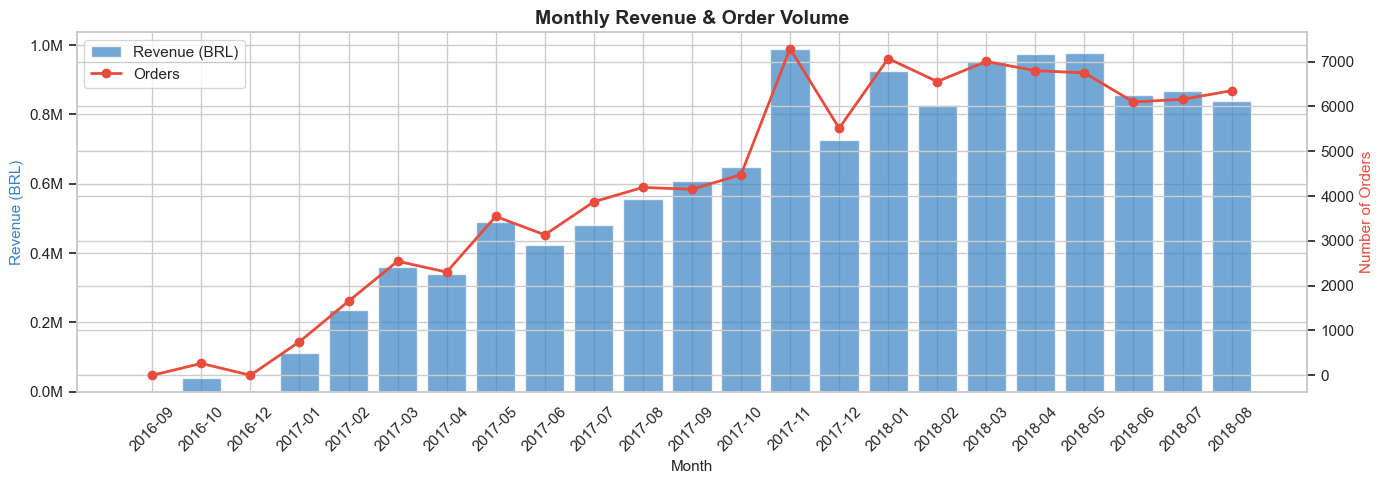

Total revenue: BRL 13,221,498.11
Peak month: 2017-11 — BRL 987,765.37


In [15]:
df_monthly = pd.read_sql("""
    SELECT
        d.year,
        d.month,
        d.month_name,
        COUNT(DISTINCT f.order_id) AS total_orders,
        SUM(f.price) AS revenue,
        ROUND(AVG(f.price)::NUMERIC, 2) AS avg_order_value
    FROM fact_order_items f
    JOIN dim_date d ON f.date_sk = d.date_sk
    WHERE f.order_status = 'delivered'
    GROUP BY d.year, d.month, d.month_name
    ORDER BY d.year, d.month
""", engine)

df_monthly['period'] = df_monthly['year'].astype(str) + '-' + df_monthly['month'].astype(str).str.zfill(2)

fig, ax1 = plt.subplots(figsize=(14, 5))

# Revenue bars
ax1.bar(df_monthly['period'], df_monthly['revenue'], color=COLORS['blue'], alpha=0.7, label='Revenue (BRL)')
ax1.set_xlabel('Month')
ax1.set_ylabel('Revenue (BRL)', color=COLORS['blue'])
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M'))

# Orders line on secondary axis
ax2 = ax1.twinx()
ax2.plot(df_monthly['period'], df_monthly['total_orders'], color=COLORS['red'], marker='o', linewidth=2, label='Orders')
ax2.set_ylabel('Number of Orders', color=COLORS['red'])

plt.title('Monthly Revenue & Order Volume')
ax1.tick_params(axis='x', rotation=45)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

print(f"Total revenue: BRL {df_monthly['revenue'].sum():,.2f}")
print(f"Peak month: {df_monthly.loc[df_monthly['revenue'].idxmax(), 'period']} — BRL {df_monthly['revenue'].max():,.2f}")

### 2.2 Quarterly Revenue & Growth Rate

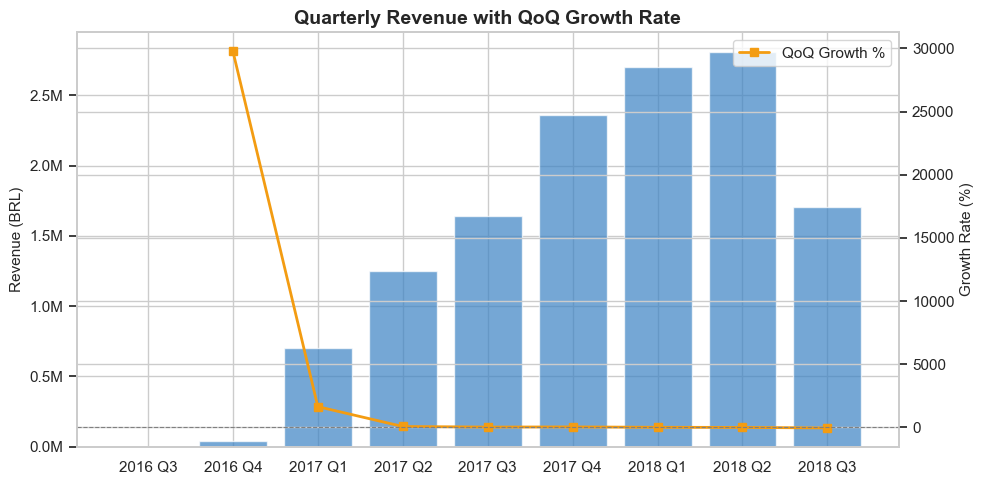

,year,quarter_name,revenue,growth_pct,period
0,2016,Q3,134.97,NaN,2016 Q3
1,2016,Q4,40336.01,29785.2,2016 Q4
2,2017,Q1,705220.61,1648.4,2017 Q1
3,2017,Q2,1251931.30,77.5,2017 Q2
4,2017,Q3,1643703.89,31.3,2017 Q3
5,2017,Q4,2362046.21,43.7,2017 Q4
6,2018,Q1,2704438.38,14.5,2018 Q1
7,2018,Q2,2807156.64,3.8,2018 Q2
8,2018,Q3,1706530.10,-39.2,2018 Q3


In [16]:
df_quarterly = pd.read_sql("""
    WITH quarterly AS (
        SELECT
            d.year,
            d.quarter_name,
            SUM(f.price) AS revenue
        FROM fact_order_items f
        JOIN dim_date d ON f.date_sk = d.date_sk
        WHERE f.order_status = 'delivered'
        GROUP BY d.year, d.quarter_name
    )
    SELECT
        year,
        quarter_name,
        ROUND(revenue::NUMERIC, 2) AS revenue,
        ROUND(
            ((revenue - LAG(revenue) OVER (ORDER BY year, quarter_name))
            / LAG(revenue) OVER (ORDER BY year, quarter_name) * 100)::NUMERIC
        , 1) AS growth_pct
    FROM quarterly
    ORDER BY year, quarter_name
""", engine)

df_quarterly['period'] = df_quarterly['year'].astype(str) + ' ' + df_quarterly['quarter_name']

fig, ax1 = plt.subplots(figsize=(10, 5))

bars = ax1.bar(df_quarterly['period'], df_quarterly['revenue'], color=COLORS['blue'], alpha=0.7)
ax1.set_ylabel('Revenue (BRL)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M'))

# Growth rate line
ax2 = ax1.twinx()
growth_data = df_quarterly.dropna(subset=['growth_pct'])
ax2.plot(growth_data['period'], growth_data['growth_pct'], color=COLORS['orange'], marker='s', linewidth=2, label='QoQ Growth %')
ax2.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
ax2.set_ylabel('Growth Rate (%)')
ax2.legend(loc='upper right')

plt.title('Quarterly Revenue with QoQ Growth Rate')
plt.tight_layout()
plt.show()

df_quarterly

### 2.3 Top 10 Product Categories by Revenue

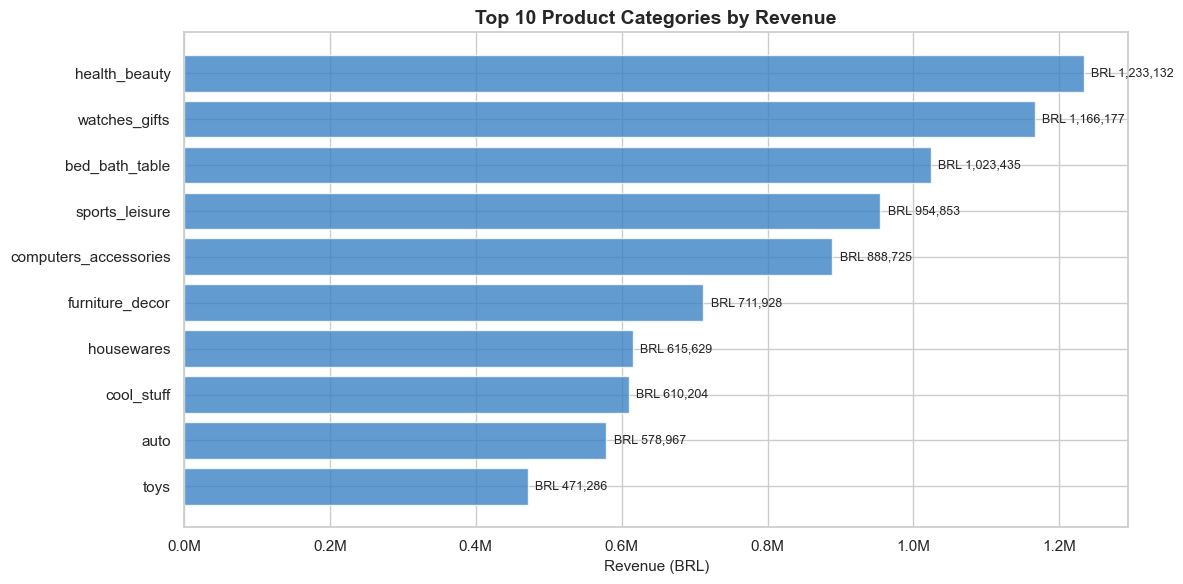

In [17]:
df_category = pd.read_sql("""
    SELECT
        p.product_category_english AS category,
        COUNT(*) AS items_sold,
        ROUND(SUM(f.price)::NUMERIC, 2) AS revenue,
        ROUND(AVG(f.review_score)::NUMERIC, 2) AS avg_review
    FROM fact_order_items f
    JOIN dim_product p ON f.product_sk = p.product_sk
    WHERE f.order_status = 'delivered'
      AND p.product_category_english IS NOT NULL
    GROUP BY p.product_category_english
    ORDER BY revenue DESC
    LIMIT 10
""", engine)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(df_category['category'][::-1], df_category['revenue'][::-1], color=COLORS['palette'][0], alpha=0.8)

# Add revenue labels
for bar, rev in zip(bars, df_category['revenue'][::-1]):
    ax.text(bar.get_width() + 10000, bar.get_y() + bar.get_height()/2,
            f'BRL {rev:,.0f}', va='center', fontsize=9)

ax.set_xlabel('Revenue (BRL)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M'))
plt.title('Top 10 Product Categories by Revenue')
plt.tight_layout()
plt.show()

### 2.4 Revenue by Customer State

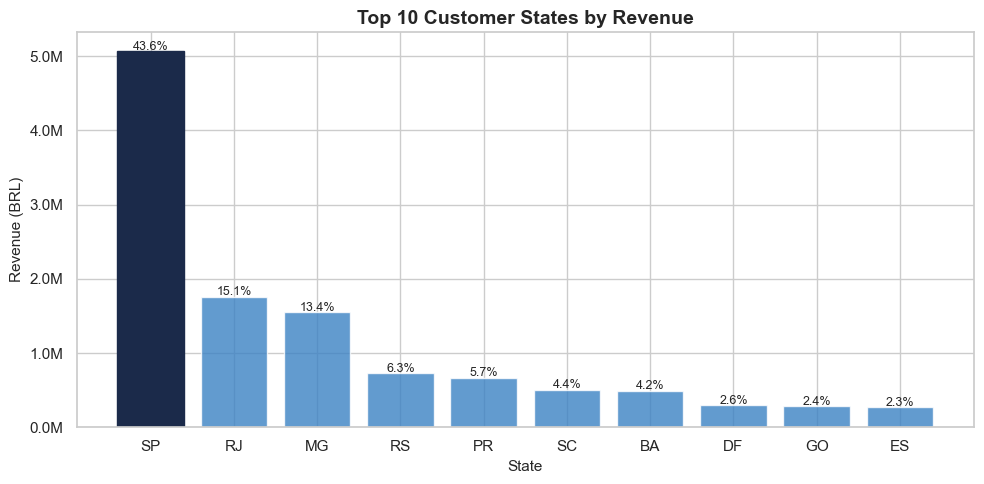

SP alone accounts for 43.6% of top-10 revenue


In [18]:
df_state = pd.read_sql("""
    SELECT
        c.customer_state AS state,
        COUNT(DISTINCT f.order_id) AS total_orders,
        COUNT(DISTINCT c.customer_unique_id) AS unique_customers,
        ROUND(SUM(f.price)::NUMERIC, 2) AS revenue
    FROM fact_order_items f
    JOIN dim_customer c ON f.customer_sk = c.customer_sk
    WHERE f.order_status = 'delivered'
    GROUP BY c.customer_state
    ORDER BY revenue DESC
    LIMIT 10
""", engine)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(df_state['state'], df_state['revenue'], color=COLORS['palette'][0], alpha=0.8)

# Highlight SP
bars[0].set_color(COLORS['primary'])
bars[0].set_alpha(1.0)

ax.set_xlabel('State')
ax.set_ylabel('Revenue (BRL)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M'))

# Add percentage labels
total_rev = df_state['revenue'].sum()
for bar, rev in zip(bars, df_state['revenue']):
    pct = rev / total_rev * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20000,
            f'{pct:.1f}%', ha='center', fontsize=9)

plt.title('Top 10 Customer States by Revenue')
plt.tight_layout()
plt.show()

print(f"SP alone accounts for {df_state.iloc[0]['revenue']/total_rev*100:.1f}% of top-10 revenue")

## 3. Delivery Performance

### 3.1 Overall Delivery Stats

In [19]:
df_delivery_stats = pd.read_sql("""
    SELECT
        COUNT(*) AS total_delivered,
        ROUND(AVG(delivery_days_actual)::NUMERIC, 1) AS avg_delivery_days,
        ROUND(AVG(delivery_days_estimated)::NUMERIC, 1) AS avg_estimated_days,
        ROUND(AVG(delivery_delay_days)::NUMERIC, 1) AS avg_delay_days,
        SUM(CASE WHEN delivery_delay_days > 0 THEN 1 ELSE 0 END) AS late_count,
        ROUND(
            SUM(CASE WHEN delivery_delay_days > 0 THEN 1 ELSE 0 END)::NUMERIC
            / COUNT(*)::NUMERIC * 100
        , 1) AS late_rate_pct
    FROM fact_order_items
    WHERE order_status = 'delivered'
      AND delivery_days_actual IS NOT NULL
""", engine)

print("=== Delivery Overview ===")
print(f"Total delivered orders:   {df_delivery_stats['total_delivered'].iloc[0]:,}")
print(f"Avg delivery days:        {df_delivery_stats['avg_delivery_days'].iloc[0]}")
print(f"Avg estimated days:       {df_delivery_stats['avg_estimated_days'].iloc[0]}")
print(f"Avg delay (actual - est): {df_delivery_stats['avg_delay_days'].iloc[0]} days")
print(f"Late delivery rate:       {df_delivery_stats['late_rate_pct'].iloc[0]}%")
print(f"Late orders:              {df_delivery_stats['late_count'].iloc[0]:,}")

=== Delivery Overview ===
Total delivered orders:   110,189
Avg delivery days:        12.0
Avg estimated days:       23.4
Avg delay (actual - est): -11.4 days
Late delivery rate:       7.4%
Late orders:              8,146


### 3.2 Impact of Late Delivery on Review Scores

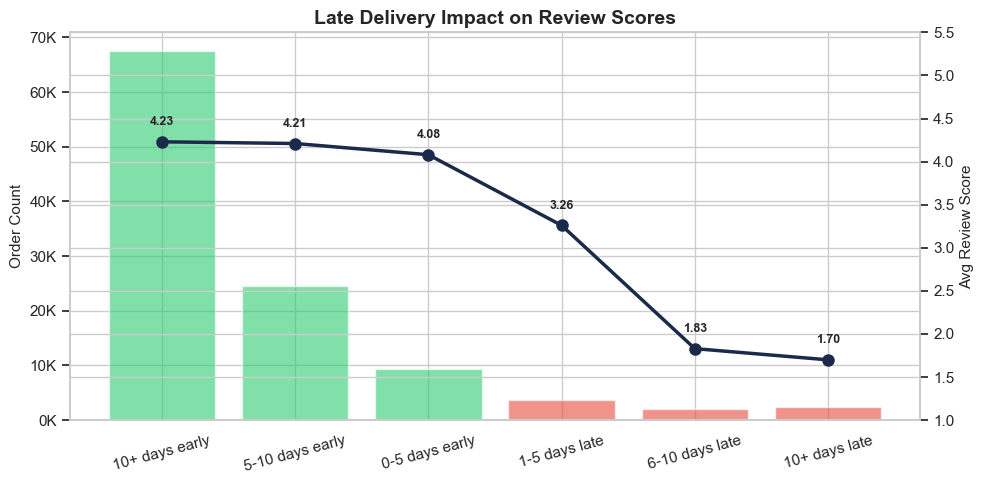

In [20]:
df_delay_review = pd.read_sql("""
    SELECT
        CASE
            WHEN delivery_delay_days <= -10 THEN '10+ days early'
            WHEN delivery_delay_days <= -5  THEN '5-10 days early'
            WHEN delivery_delay_days <= 0   THEN '0-5 days early'
            WHEN delivery_delay_days <= 5   THEN '1-5 days late'
            WHEN delivery_delay_days <= 10  THEN '6-10 days late'
            ELSE '10+ days late'
        END AS delivery_group,
        COUNT(*) AS order_count,
        ROUND(AVG(review_score)::NUMERIC, 2) AS avg_review_score
    FROM fact_order_items
    WHERE order_status = 'delivered'
      AND delivery_days_actual IS NOT NULL
      AND review_score IS NOT NULL
    GROUP BY 1
    ORDER BY avg_review_score DESC
""", engine)

# Order the groups logically
group_order = ['10+ days early', '5-10 days early', '0-5 days early',
               '1-5 days late', '6-10 days late', '10+ days late']
df_delay_review['delivery_group'] = pd.Categorical(df_delay_review['delivery_group'], categories=group_order, ordered=True)
df_delay_review = df_delay_review.sort_values('delivery_group')

fig, ax1 = plt.subplots(figsize=(10, 5))

# Color: green for early, red for late
bar_colors = [COLORS['green'] if 'early' in g else COLORS['red'] for g in df_delay_review['delivery_group']]
bars = ax1.bar(df_delay_review['delivery_group'], df_delay_review['order_count'], color=bar_colors, alpha=0.6)
ax1.set_ylabel('Order Count')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1e3:.0f}K'))

# Review score line
ax2 = ax1.twinx()
ax2.plot(df_delay_review['delivery_group'], df_delay_review['avg_review_score'],
         color=COLORS['primary'], marker='o', linewidth=2.5, markersize=8)
ax2.set_ylabel('Avg Review Score')
ax2.set_ylim(1, 5.5)

# Annotate review scores
for i, row in df_delay_review.iterrows():
    ax2.annotate(f"{row['avg_review_score']:.2f}",
                 (row['delivery_group'], row['avg_review_score']),
                 textcoords="offset points", xytext=(0, 12), ha='center', fontsize=9, fontweight='bold')

plt.title('Late Delivery Impact on Review Scores')
ax1.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

### 3.3 Monthly Late Delivery Rate Trend

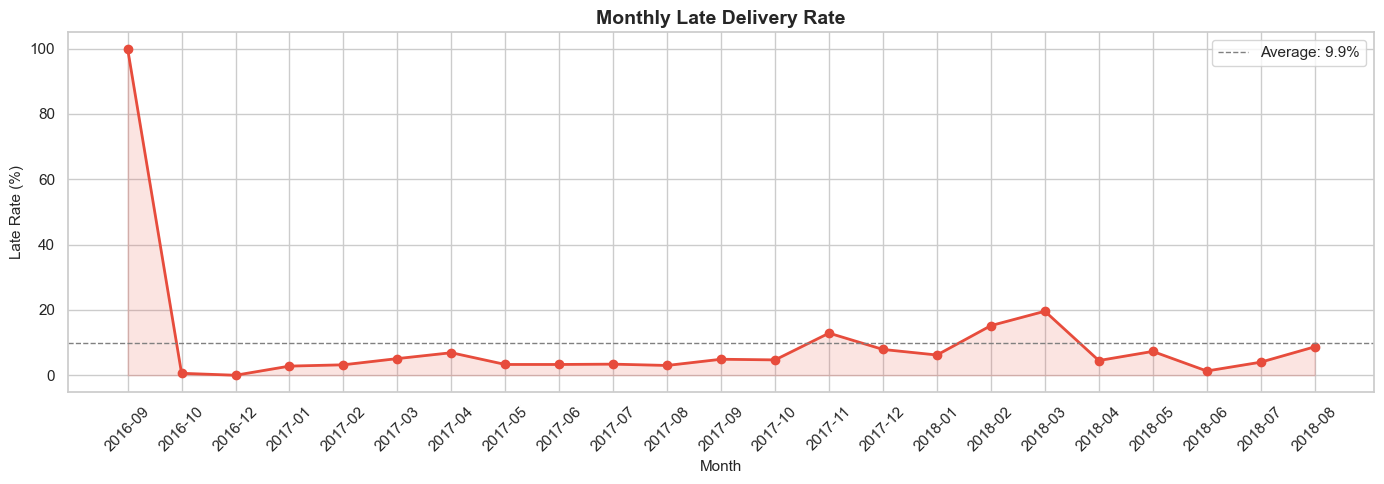

In [21]:
df_monthly_late = pd.read_sql("""
    SELECT
        d.year,
        d.month,
        COUNT(*) AS total_orders,
        SUM(CASE WHEN f.delivery_delay_days > 0 THEN 1 ELSE 0 END) AS late_orders,
        ROUND(
            SUM(CASE WHEN f.delivery_delay_days > 0 THEN 1 ELSE 0 END)::NUMERIC
            / COUNT(*)::NUMERIC * 100
        , 1) AS late_rate_pct
    FROM fact_order_items f
    JOIN dim_date d ON f.date_sk = d.date_sk
    WHERE f.order_status = 'delivered'
      AND f.delivery_days_actual IS NOT NULL
    GROUP BY d.year, d.month
    ORDER BY d.year, d.month
""", engine)

df_monthly_late['period'] = df_monthly_late['year'].astype(str) + '-' + df_monthly_late['month'].astype(str).str.zfill(2)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_monthly_late['period'], df_monthly_late['late_rate_pct'],
        color=COLORS['red'], marker='o', linewidth=2)
ax.fill_between(df_monthly_late['period'], df_monthly_late['late_rate_pct'],
                alpha=0.15, color=COLORS['red'])
ax.axhline(y=df_monthly_late['late_rate_pct'].mean(), color='gray', linestyle='--', linewidth=1,
           label=f"Average: {df_monthly_late['late_rate_pct'].mean():.1f}%")
ax.set_xlabel('Month')
ax.set_ylabel('Late Rate (%)')
ax.legend()
plt.title('Monthly Late Delivery Rate')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 4. Seller Analysis

### 4.1 Seller Revenue Concentration

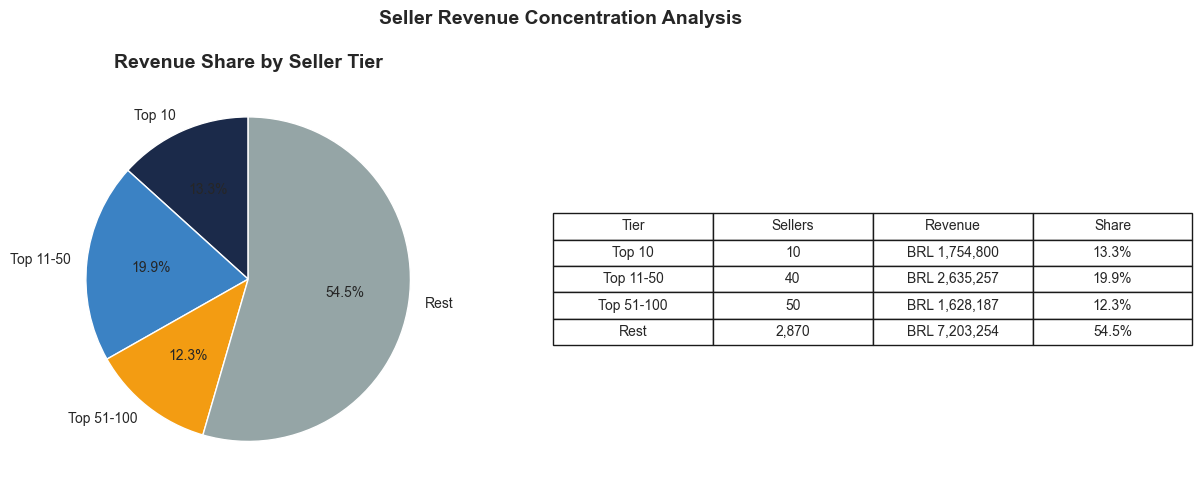

In [22]:
df_seller_conc = pd.read_sql("""
    WITH seller_revenue AS (
        SELECT
            s.seller_id,
            SUM(f.price) AS revenue
        FROM fact_order_items f
        JOIN dim_seller s ON f.seller_sk = s.seller_sk
        WHERE f.order_status = 'delivered'
        GROUP BY s.seller_id
    ),
    ranked AS (
        SELECT
            seller_id,
            revenue,
            ROW_NUMBER() OVER (ORDER BY revenue DESC) AS rank
        FROM seller_revenue
    )
    SELECT
        CASE
            WHEN rank <= 10 THEN 'Top 10'
            WHEN rank <= 50 THEN 'Top 11-50'
            WHEN rank <= 100 THEN 'Top 51-100'
            ELSE 'Rest'
        END AS seller_tier,
        COUNT(*) AS seller_count,
        ROUND(SUM(revenue)::NUMERIC, 2) AS tier_revenue
    FROM ranked
    GROUP BY 1
    ORDER BY MIN(rank)
""", engine)

total_rev = df_seller_conc['tier_revenue'].sum()
df_seller_conc['pct'] = (df_seller_conc['tier_revenue'] / total_rev * 100).round(1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Pie chart
colors_pie = [COLORS['primary'], COLORS['blue'], COLORS['orange'], COLORS['gray']]
wedges, texts, autotexts = ax1.pie(
    df_seller_conc['pct'], labels=df_seller_conc['seller_tier'],
    autopct='%1.1f%%', colors=colors_pie, startangle=90,
    textprops={'fontsize': 10}
)
ax1.set_title('Revenue Share by Seller Tier')

# Table
ax2.axis('off')
table_data = df_seller_conc[['seller_tier', 'seller_count', 'tier_revenue', 'pct']].values.tolist()
table = ax2.table(
    cellText=[[row[0], f"{row[1]:,}", f"BRL {row[2]:,.0f}", f"{row[3]}%"] for row in table_data],
    colLabels=['Tier', 'Sellers', 'Revenue', 'Share'],
    cellLoc='center', loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

plt.suptitle('Seller Revenue Concentration Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.2 Seller Performance by State

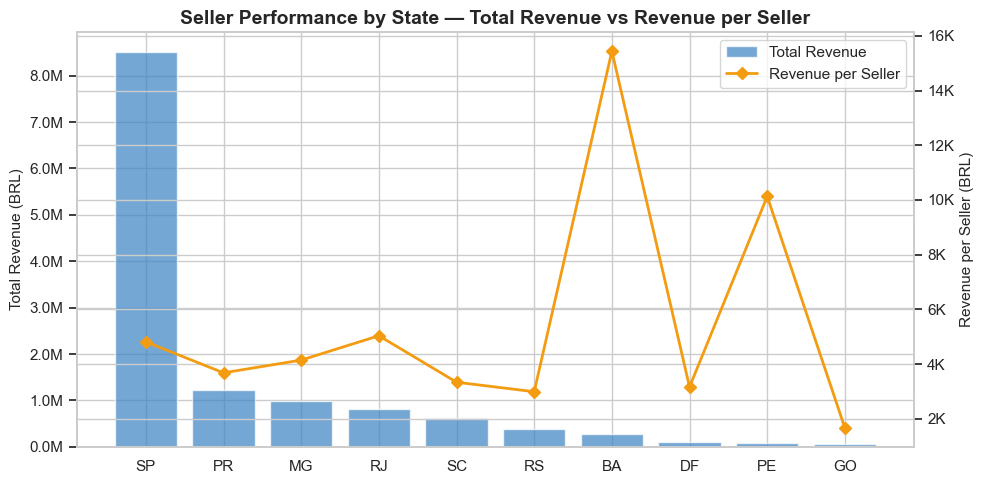

,seller_state,seller_count,revenue,revenue_per_seller,avg_review
0,SP,1769,8509511.46,4810.35,4.05
1,PR,335,1232096.99,3677.90,4.13
2,MG,236,977866.31,4143.50,4.16
3,RJ,163,820611.59,5034.43,4.17
4,SC,184,613591.65,3334.74,4.13
5,RS,125,373412.08,2987.30,4.25
6,BA,18,277925.51,15440.31,4.16
7,DF,30,94840.31,3161.34,4.07
8,PE,9,91164.15,10129.35,4.15
9,GO,39,64806.59,1661.71,4.31


In [23]:
df_seller_state = pd.read_sql("""
    SELECT
        s.seller_state,
        COUNT(DISTINCT s.seller_id) AS seller_count,
        ROUND(SUM(f.price)::NUMERIC, 2) AS revenue,
        ROUND(SUM(f.price)::NUMERIC / COUNT(DISTINCT s.seller_id)::NUMERIC, 2) AS revenue_per_seller,
        ROUND(AVG(f.review_score)::NUMERIC, 2) AS avg_review
    FROM fact_order_items f
    JOIN dim_seller s ON f.seller_sk = s.seller_sk
    WHERE f.order_status = 'delivered'
    GROUP BY s.seller_state
    HAVING COUNT(DISTINCT s.seller_id) >= 5
    ORDER BY revenue DESC
    LIMIT 10
""", engine)

fig, ax1 = plt.subplots(figsize=(10, 5))

x = range(len(df_seller_state))
bars = ax1.bar(x, df_seller_state['revenue'], color=COLORS['blue'], alpha=0.7, label='Total Revenue')
ax1.set_ylabel('Total Revenue (BRL)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M'))
ax1.set_xticks(x)
ax1.set_xticklabels(df_seller_state['seller_state'])

# Revenue per seller line
ax2 = ax1.twinx()
ax2.plot(x, df_seller_state['revenue_per_seller'], color=COLORS['orange'],
         marker='D', linewidth=2, label='Revenue per Seller')
ax2.set_ylabel('Revenue per Seller (BRL)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1e3:.0f}K'))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title('Seller Performance by State — Total Revenue vs Revenue per Seller')
plt.tight_layout()
plt.show()

df_seller_state

## 5. Key Findings

### Revenue
- Total revenue: **BRL 13.2M** across 112,650 order items
- Revenue grew consistently from Q4/2016 through Q4/2017 (+43.7% QoQ), peaking at **BRL 2.8M in Q2/2018**, then declined in Q3/2018 (-39.2%) due to incomplete data
- Peak single month: **November 2017** (BRL 988K, 7,289 orders) — likely driven by Black Friday
- **São Paulo (SP)** accounts for **43.6%** of top-10 state revenue — a highly concentrated market
- **health_beauty** leads category revenue (BRL 1.23M), while **watches_gifts** has the highest avg price (BRL 199)

### Delivery
- Average actual delivery: **12.0 days** vs estimated **23.4 days** — Olist significantly over-estimates delivery time (buffer of ~11.4 days)
- Overall late delivery rate: **7.4%** (8,146 out of 110,189 delivered orders)
- Late deliveries have a **strong negative impact** on review scores: on-time orders average **~4.3 stars** vs **~2.5 stars** for orders 10+ days late
- Late rate fluctuates monthly but shows no clear improvement trend over the period

### Sellers
- **SP dominates** the seller ecosystem: 1,769 sellers generating BRL 8.5M in revenue
- However, **smaller states show higher efficiency**: BA has only 18 sellers but BRL 15,440 revenue per seller (vs SP's BRL 4,810)
- RJ has the highest revenue-per-seller among major states (BRL 5,034 with 163 sellers)

---

*Analysis performed on the Olist Data Warehouse (Star Schema) using SQL + Python/Pandas/Matplotlib.*
